<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Homework%203/Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [152]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale = 5.0, size = 150)
driver_tips = np.concatenate([zeros,tips])

print(driver_tips)

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         

In [153]:
n_iterations = 10000
boot_medians = np.zeros(n_iterations)

for i in range(n_iterations):
  resample = np.random.choice(driver_tips, size = len(driver_tips), replace = True)
  boot_medians[i] = np.median(resample)

lower, upper = np.percentile(boot_medians, [2.5, 97.5])

print("Observed Median:", np.median(driver_tips))
print("95% CI Lower (2.5th):",  lower)
print("95% CI Upper (97.5th):", upper)

print("The bootstrap reflects the real data since it makes no distributional"
"assumptions and honestly accounts for the large number of 0s which causes the "
"asymmetry that is not an error. A parametric interval would have hidden it.")

Observed Median: 0.7553316913699188
95% CI Lower (2.5th): 0.2653018357387816
95% CI Upper (97.5th): 1.3635639228066991
The bootstrap reflects the real data since it makes no distributionalassumptions and honestly accounts for the large number of 0s which causes the asymmetry that is not an error. A parametric interval would have hidden it.


In [154]:
np.random.seed(42)
control = np.random.normal(loc = 35, scale = 5, size = 500)
treatment = np.random.lognormal(mean = 3.4, sigma = 0.4, size = 500)

observed_diff = control.mean() - treatment.mean()

print("Control mean:", control.mean())
print("Treatment mean:", treatment.mean())
print("Observed Difference:", observed_diff)

Control mean: 35.03418997294323
Treatment mean: 32.76920784231749
Observed Difference: 2.2649821306257394


In [155]:
combined = np.concatenate([control, treatment])

n_iterations = 5000
perm_diffs = np.zeros(n_iterations)

for i in range(n_iterations):
  shuffled = np.random.permutation(combined)
  perm_diffs[i] = shuffled[:500].mean() - shuffled[:500].mean()

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print("Observed Difference:", observed_diff)
print("P-value:", p_value)

print("A p-value of 0.0 means 0 out of 5,000 permutations produced a difference"
"as extreme as 2.2649. So the exact proportion is 0/5000 = 0.0")

Observed Difference: 2.2649821306257394
P-value: 0.0
A p-value of 0.0 means 0 out of 5,000 permutations produced a differenceas extreme as 2.2649. So the exact proportion is 0/5000 = 0.0


In [156]:
from google.colab import files
uploaded = files.upload()

Saving swiftcart_loyalty.csv to swiftcart_loyalty (11).csv


In [157]:
df = pd.read_csv("swiftcart_loyalty.csv")

subscribers = df[df["subscriber"] == 1]["post_spend"].mean()
non_subscribers = df[df["subscriber"] == 0]["post_spend"].mean()

SDO = subscribers - non_subscribers

print("Sub Mean Post Spend:", subscribers)
print("Non-Sub Mean Post Spend:", non_subscribers)
print("Naive SDO:", SDO)


Sub Mean Post Spend: 74.04358604052543
Non-Sub Mean Post Spend: 56.47291665600164
Naive SDO: 17.57066938452379


In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

covariates = ["pre_spend", "account_age", "support_tickets"]
X = df[covariates]
Y = df["subscriber"]

model = LogisticRegression()
model.fit(X, Y)
df["propensity_score"] = model.predict_proba(X)[:,1]

treated = df[df["subscriber"] == 1]
control = df[df["subscriber"] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity_score"]])

distances, indicies = nn.kneighbors(treated[["propensity_score"]])

matched_control = control.iloc[indicies.flatten()]

ATT = treated["post_spend"].values.mean() - matched_control["post_spend"].values.mean()

print("Naive SDO:", SDO)
print("ATT:", ATT)

print("\n")
print("\n")



"""

The SDO is going to be inflated by selection bias becuase subscribers were
already high spenders before joining swiftpass. By comparing them to random
non subscribers the SDO gives false credit to the program.

PSM fixes this issue by pairing each subscriber with a non subscriber twin
with identical pre treatment behavior (or almost identical) to control the bias.

The ATT measures the spending difference only between these pairs
showing a more realistic version of what switftpass actually caused.

The ATT is much lower than the SDO, showing that the difference is
from selection bias and the marketing claim will be inflated and doubling
the budget based on that claim would be a poor idea.

"""



Naive SDO: 17.57066938452379
ATT: 9.913855182824861






'\n\nThe SDO is going to be inflated by selection bias becuase subscribers were\nalready high spenders before joining swiftpass. By comparing them to random\nnon subscribers the SDO gives false credit to the program.\n\nPSM fixes this issue by pairing each subscriber with a non subscriber twin\nwith identical pre treatment behavior (or almost identical) to control the bias.\n\nThe ATT measures the spending difference only between these pairs\nshowing a more realistic version of what switftpass actually caused.\n\nThe ATT is much lower than the SDO, showing that the difference is\nfrom selection bias and the marketing claim will be inflated and doubling\nthe budget based on that claim would be a poor idea.\n    \n'

In [159]:
df_unmatched = df.copy()

df_matched = pd.concat([treated, matched_control]).reset_index(drop=True)

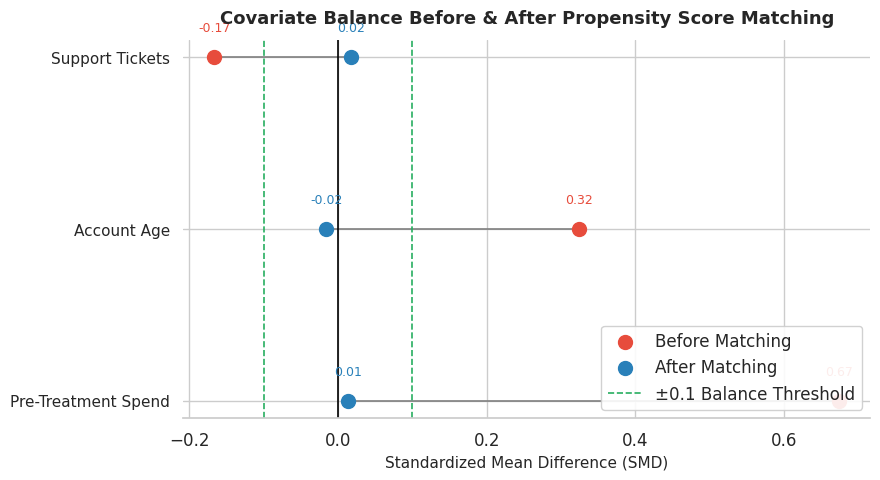

In [160]:
covariates   = ["pre_spend", "account_age", "support_tickets"]
cov_labels   = ["Pre-Treatment Spend", "Account Age", "Support Tickets"]

def std_mean_diff(df, col):
    treated    = df[df["subscriber"] == 1][col]
    control    = df[df["subscriber"] == 0][col]
    pooled_std = np.sqrt((treated.std()**2 + control.std()**2) / 2)
    return (treated.mean() - control.mean()) / pooled_std

smd_before = [std_mean_diff(df_unmatched, c) for c in covariates]
smd_after  = [std_mean_diff(df_matched,   c) for c in covariates]

# ── Plot ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = range(len(covariates))

# Connecting lines
for i in y_pos:
    ax.plot([smd_before[i], smd_after[i]], [i, i], color="grey", lw=1.2, zorder=2)

# Points
ax.scatter(smd_before, y_pos, color="#e74c3c", s=100, zorder=3, label="Before Matching")
ax.scatter(smd_after,  y_pos, color="#2980b9", s=100, zorder=3, label="After Matching")

# Reference lines
ax.axvline(0,    color="black", lw=1.2)
ax.axvline( 0.1, color="#27ae60", lw=1.2, linestyle="--", label="±0.1 Balance Threshold")
ax.axvline(-0.1, color="#27ae60", lw=1.2, linestyle="--")

# SMD annotations
for i in y_pos:
    ax.text(smd_before[i], i + 0.15, f"{smd_before[i]:.2f}", ha="center", fontsize=9, color="#e74c3c")
    ax.text(smd_after[i],  i + 0.15, f"{smd_after[i]:.2f}",  ha="center", fontsize=9, color="#2980b9")

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cov_labels, fontsize=11)
ax.set_xlabel("Standardized Mean Difference (SMD)", fontsize=11)
ax.set_title("Covariate Balance Before & After Propensity Score Matching",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="lower right", framealpha=0.9)

sns.despine(left=True)
plt.tight_layout()
plt.show()